# 📊 EDA — Final_Data Sentiment Reviews

> **Dataset:** `data/raw/Final_Data.csv`
> **Goal:** Understand data quality, class distribution, text characteristics, and derive concrete preprocessing requirements.

---

## 1 · Load & Sanity Check
Shape, columns, dtypes, null counts, sample rows rendered RTL. Confirm encoding (no mojibake).

In [29]:
import hashlib
import re
import warnings
from collections import Counter

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from utils.eda_json_tracker import update_section
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["figure.figsize"] = (12, 5)

DATA_PATH = "../data/raw/Final_Data.csv"

In [ ]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
shape_before = df.shape
print(f"Shape before null drop: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
display(df.dtypes.to_frame("dtype"))
print()
display(df.isnull().sum().to_frame("null_count"))

# Drop nulls in review_description
df = df.dropna(subset=["review_description"]).reset_index(drop=True)
print(f"\nShape after null drop: {df.shape}")

update_section(
    "data_quality",
    {
        "shape_before": list(shape_before),
        "columns": list(df.columns),
        "dtypes": df.dtypes.astype(str).to_dict(),
        "null_counts": df.isnull().sum().to_dict(),
        "shape_after_null_drop": list(df.shape),
        "null_rows_dropped": shape_before[0] - df.shape[0],
    },
)

Shape before null drop: (40046, 3)
Columns: ['review_description', 'rating', 'company']



,dtype
review_description,object
rating,object
company,object


,null_count
review_description,1
rating,0
company,0



Shape after null drop: (40045, 3)


In [31]:
# RTL sample rows — confirms encoding is correct (no mojibake)
sample = df.sample(5, random_state=42)
html = '<div dir="rtl" style="text-align:right; font-size:14px;">'

color_map = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#f39c12"}

for _, row in sample.iterrows():
    label_color = color_map.get(row["rating"], "#34495e")
    html += (
        f'<p><span style="color:{label_color};font-weight:bold;">'
        f"[rating={row['rating']}, company={row['company']}]</span> {row['review_description'][:300]}…</p><hr>"
    )
html += "</div>"
display(HTML(html))

## 2 · Label Distribution
Counts & percentages per class.

>  The original project checklist targets 45% Pos / 35% Neg / 20% Neu. Let's compare the actual distribution against this target.


,count,pct (%)
rating,,
positive,23921,59.74
negative,14199,35.46
neutral,1925,4.81


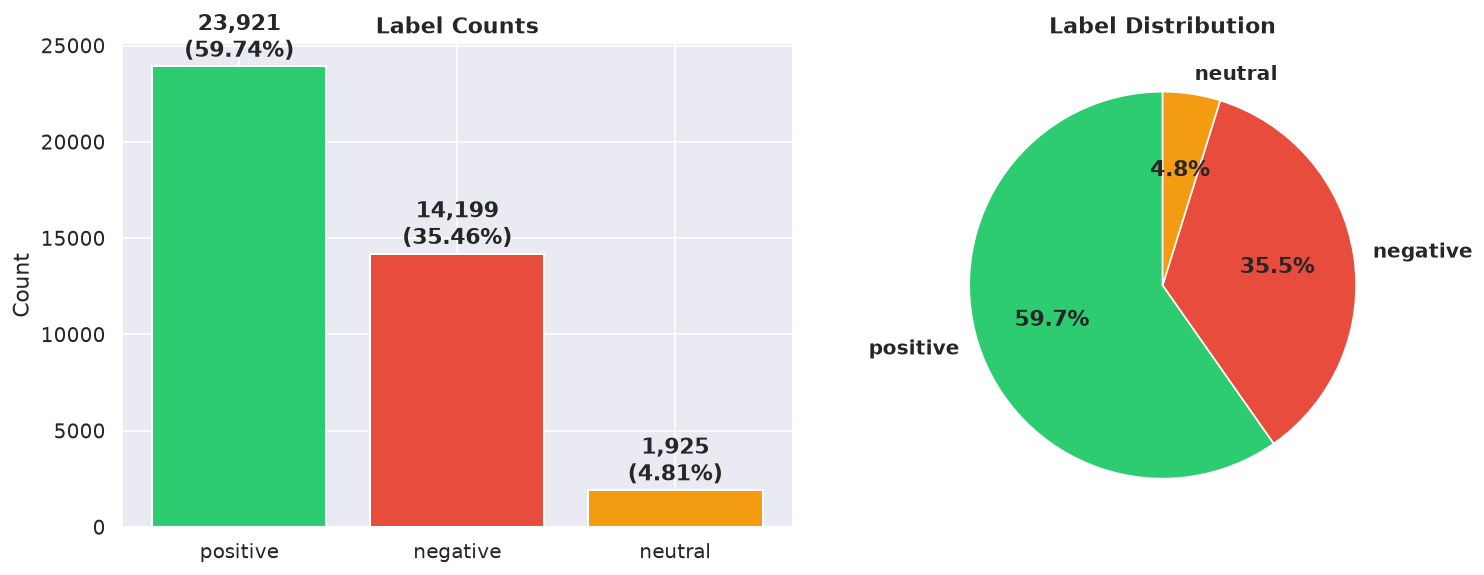


 Target vs. Actual:
  Target  → 45% Pos / 35% Neg / 20% Neu
  Actual  → 59.7% Pos / 35.5% Neg / 4.8% Neu


In [32]:
counts = df["rating"].value_counts()
pcts = (counts / len(df) * 100).round(2)

summary = pd.DataFrame({"count": counts, "pct (%)": pcts})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Align colors
colors = [color_map.get(lbl, "#34495e") for lbl in summary.index]

# Bar chart
axes[0].bar(
    summary.index, summary["count"], color=colors, edgecolor="white", linewidth=1.2
)
for i, (v, p) in enumerate(zip(summary["count"], summary["pct (%)"])):
    axes[0].text(i, v + 500, f"{v:,}\n({p}%)", ha="center", fontweight="bold")
axes[0].set_title("Label Counts", fontweight="bold")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(
    summary["count"],
    labels=summary.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    textprops={"fontweight": "bold"},
)
axes[1].set_title("Label Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

# Compare against target
print("\n Target vs. Actual:")
print("  Target  → 45% Pos / 35% Neg / 20% Neu")
print(
    f"  Actual  → {pcts.get('positive', 0):.1f}% Pos / {pcts.get('negative', 0):.1f}% Neg / {pcts.get('neutral', 0):.1f}% Neu"
)

fig.savefig(
    r"../reports/eda/Final_Data_first_data_only/figures/label_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

update_section(
    "label_distribution",
    {
        "counts": counts.to_dict(),
        "percentages": pcts.to_dict(),
        "target_percentages": {"positive": 45.0, "negative": 35.0, "neutral": 20.0},
    },
)

## 3 · Text Length Distribution
Character & word count histograms by class. These distributions form the **baseline for PSI drift monitoring** in production.

In [33]:
df["char_len"] = df["review_description"].astype(str).str.len()
df["word_count"] = df["review_description"].astype(str).str.split().str.len()

print("Overall text-length statistics:")
display(df[["char_len", "word_count"]].describe().round(1))

update_section(
    "text_statistics",
    {
        "character_length": df["char_len"].describe().round(1).to_dict(),
        "word_count": df["word_count"].describe().round(1).to_dict(),
    },
)

Overall text-length statistics:


,char_len,word_count
count,40045.0,40045.0
mean,50.8,9.4
std,68.3,12.5
min,1.0,1.0
25%,14.0,3.0
50%,28.0,5.0
75%,60.0,11.0
max,2481.0,443.0


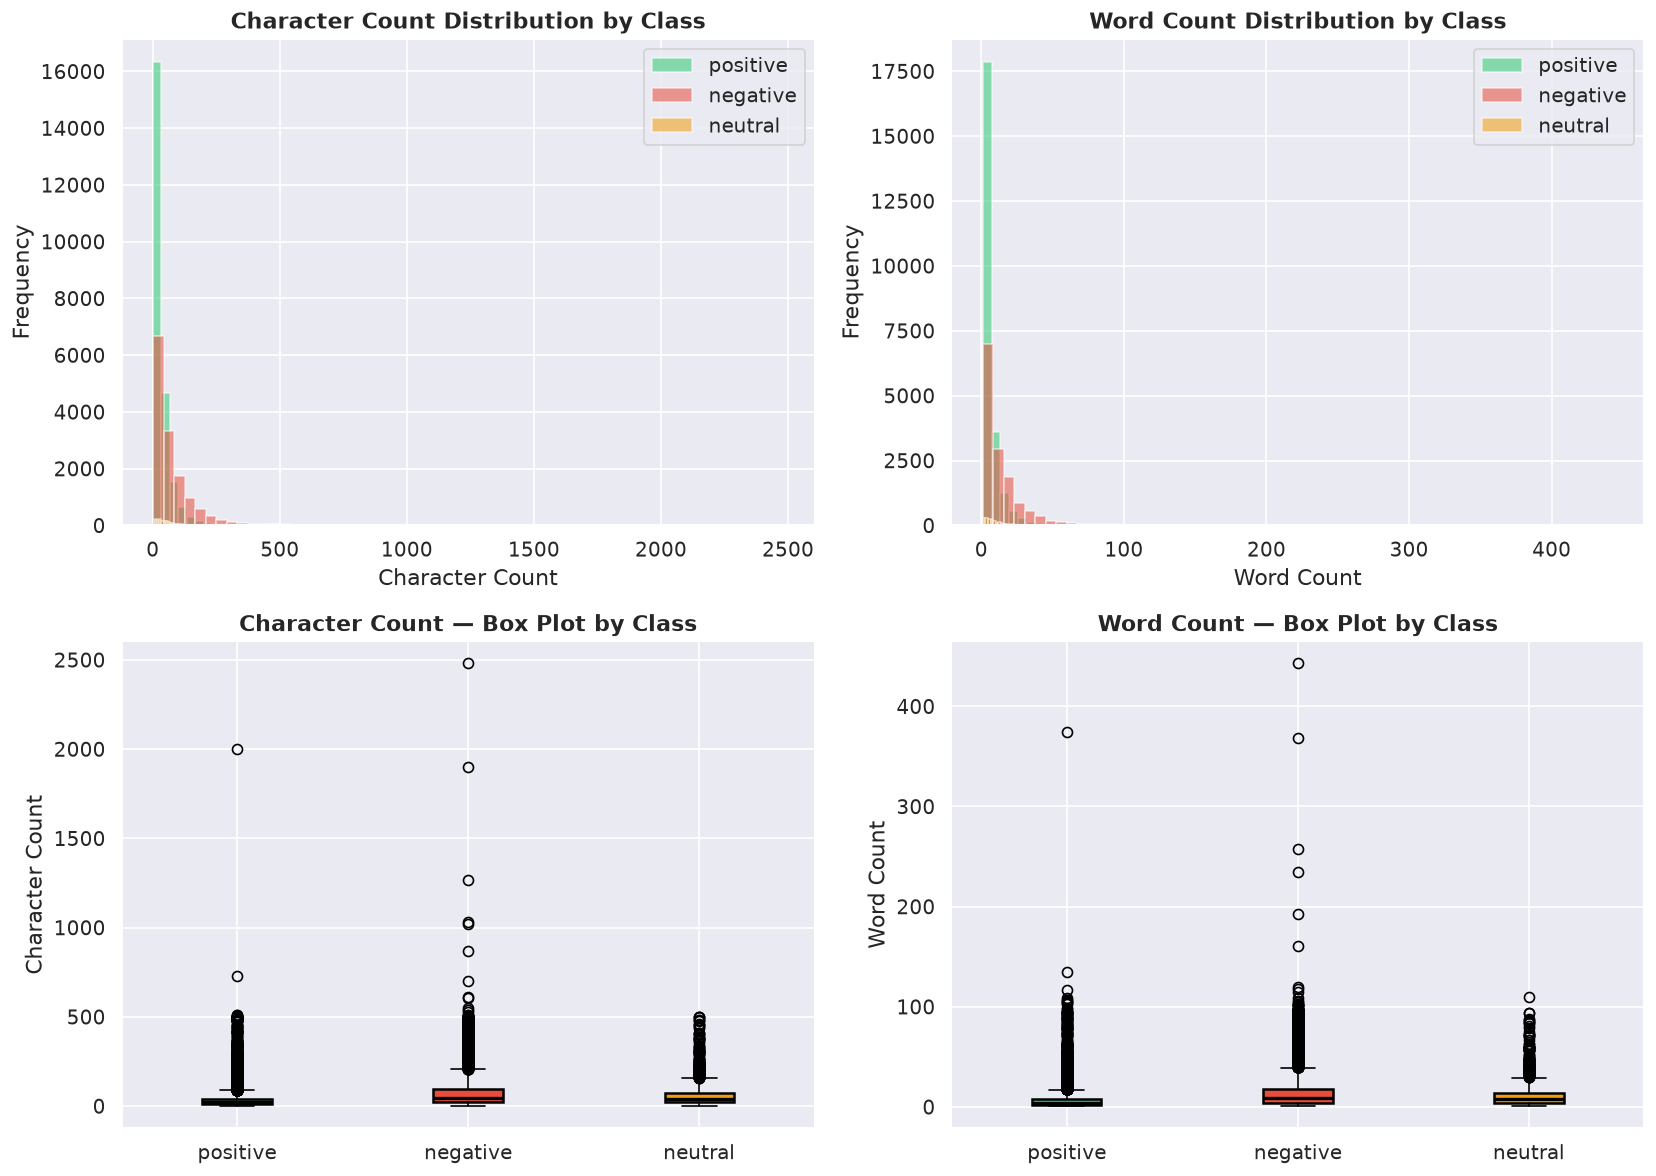


 Per-class text length stats (PSI baseline):


rating            negative  neutral  positive
char_len   count   14199.0   1925.0   23921.0
           mean       74.8     61.8      35.7
           std        87.3     67.7      48.2
           min         1.0      1.0       1.0
           25%        21.0     21.0      11.0
           50%        46.0     42.0      22.0
           75%        96.0     75.0      42.0
           max      2481.0    500.0    1998.0
word_count count   14199.0   1925.0   23921.0
           mean       14.0     11.5       6.4
           std        16.3     12.4       8.4
           min         1.0      1.0       1.0
           25%         4.0      4.0       2.0
           50%         9.0      8.0       4.0
           75%        18.0     14.0       8.0
           max       443.0    110.0     374.0

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
classes = ["positive", "negative", "neutral"]
colors_list = [color_map[c] for c in classes]

for i, (col, title) in enumerate(
    [("char_len", "Character Count"), ("word_count", "Word Count")]
):
    # Histogram by class
    ax = axes[0, i]
    for label, color in zip(classes, colors_list):
        subset = df[df["rating"] == label][col]
        if not subset.empty:
            ax.hist(
                subset, bins=60, alpha=0.55, color=color, label=label, edgecolor="white"
            )
    ax.set_title(f"{title} Distribution by Class", fontweight="bold")
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency")
    ax.legend()

    # Box plot by class
    ax2 = axes[1, i]
    data_to_plot = [df[df["rating"] == lbl][col] for lbl in classes]

    # Filter out empty data
    non_empty_data = [d for d in data_to_plot if not d.empty]
    non_empty_labels = [classes[j] for j, d in enumerate(data_to_plot) if not d.empty]
    non_empty_colors = [
        colors_list[j] for j, d in enumerate(data_to_plot) if not d.empty
    ]

    if non_empty_data:
        bp = ax2.boxplot(
            non_empty_data,
            tick_labels=non_empty_labels,
            patch_artist=True,
            boxprops={"linewidth": 1.5},
            medianprops={"color": "black", "linewidth": 2},
        )
        for box, color in zip(bp["boxes"], non_empty_colors):
            box.set_facecolor(color)
    ax2.set_title(f"{title} — Box Plot by Class", fontweight="bold")
    ax2.set_ylabel(title)

plt.tight_layout()
plt.show()

# Per-class stats for PSI baseline
print("\n Per-class text length stats (PSI baseline):")
display(df.groupby("rating")[["char_len", "word_count"]].describe().round(1).T)

fig.savefig(
    r"../reports/eda/Final_Data_first_data_only/figures/text_length_dist.png",
    dpi=150,
    bbox_inches="tight",
)

## 4 · Duplicate / Near-Duplicate Check
Exact duplicate rate + hash-based near-duplicate detection.

In [ ]:
# Exact duplicates based on description
exact_dupes = df["review_description"].duplicated()
n_exact = exact_dupes.sum()
print(f"Exact duplicate reviews: {n_exact} ({n_exact / len(df) * 100:.2f}%)")

# Show some duplicates
if n_exact > 0:
    dup_texts = (
        df[df["review_description"].duplicated(keep=False)]
        .sort_values("review_description")
        .head(10)
    )
    display(dup_texts)

update_section(
    "duplicates",
    {
        "exact_count": (n_exact),
        "exact_percentage": round(n_exact / len(df) * 100, 2),
    },
)

Exact duplicate reviews: 1042 (2.60%)


,review_description,rating,company,char_len,word_count
6193,100 100,positive,talbat,7,2
39037,100 100,positive,telecom_egypt,7,2
2571,100/100,positive,talbat,7,1
37640,100/100,positive,telecom_egypt,7,1
37263,Bad,negative,telecom_egypt,3,1
37043,Bad,negative,Raya,3,1
32695,Bad,negative,swvl,3,1
763,Bad,negative,talbat,3,1
32273,Bad app,negative,swvl,7,2
37699,Bad app,negative,telecom_egypt,7,2


In [36]:
# Near-duplicate check using normalized text hashing
def normalize_for_dedup(text):
    """Light normalization for near-duplicate detection."""
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)  # collapse whitespace
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)  # keep only Arabic + spaces
    text = text.strip()
    return text


df["_norm_hash"] = df["review_description"].apply(
    lambda x: hashlib.md5(normalize_for_dedup(x).encode()).hexdigest()
)
near_dupes = df["_norm_hash"].duplicated()
n_near = near_dupes.sum()
print(
    f"Near-duplicates (after normalization): {n_near} ({n_near / len(df) * 100:.2f}%)"
)

# Check if near-dupes have conflicting labels
if n_near > 0:
    dup_hashes = df[df["_norm_hash"].duplicated(keep=False)]
    conflicting = dup_hashes.groupby("_norm_hash")["rating"].nunique()
    n_conflict = (conflicting > 1).sum()
    print(f"Near-duplicate groups with conflicting labels: {n_conflict}")

df.drop(columns=["_norm_hash"], inplace=True)

Near-duplicates (after normalization): 3967 (9.91%)
Near-duplicate groups with conflicting labels: 142


## 5 · Script & Noise Patterns
Percentage of reviews with Arabizi, emojis, embedded English, diacritics, elongated characters. Each finding → a normalization rule.

In [37]:
content = df["review_description"].astype(str)

# Pattern detectors
patterns = {}

# Arabic script presence
arabic_re = re.compile(r"[\u0600-\u06FF]")
patterns["Has Arabic script"] = content.str.contains(arabic_re).sum()

# Latin characters (Arabizi / embedded English)
patterns["Has Latin chars"] = content.str.contains(r"[a-zA-Z]", regex=True).sum()

# Emoji
emoji_re = re.compile(
    "[\U0001f600-\U0001f64f\U0001f300-\U0001f5ff\U0001f680-\U0001f6ff"
    "\U0001f1e0-\U0001f1ff\U00002702-\U000027b0\U0001f900-\U0001f9ff"
    "\U0001fa00-\U0001fa6f\U0001fa70-\U0001faff\U00002600-\U000026ff]"
)
patterns["Has emojis"] = content.str.contains(emoji_re).sum()

# Diacritics (tashkeel)
diacritics_re = re.compile("[\u064b-\u065f\u0670]")
patterns["Has diacritics"] = content.str.contains(diacritics_re).sum()

# Elongated repeated characters (e.g. جدااااا)
elongated_re = re.compile(r"(.)\1{2,}")
patterns["Has elongated chars"] = content.str.contains(elongated_re).sum()

# Numbers
patterns["Has digits"] = content.str.contains(r"\d", regex=True).sum()

# Punctuation heavy (>10 punctuation chars)
patterns["Heavy punctuation (>10)"] = (
    content.str.count(r"[!?.,:;()\[\]{}]") > 10
).sum()

# Build summary
noise_df = pd.DataFrame(
    {
        "count": patterns.values(),
        "pct (%)": [round(v / len(df) * 100, 2) for v in patterns.values()],
    },
    index=patterns.keys(),
)
display(noise_df.style.bar(subset=["pct (%)"], color="#5fba7d"))

update_section("noise_patterns", noise_df.to_dict(orient="index"))

,count,pct (%)
Has Arabic script,38100,95.140000
Has Latin chars,1635,4.080000
Has emojis,4788,11.960000
Has diacritics,914,2.280000
Has elongated chars,5921,14.790000
Has digits,2765,6.900000
Heavy punctuation (>10),199,0.500000


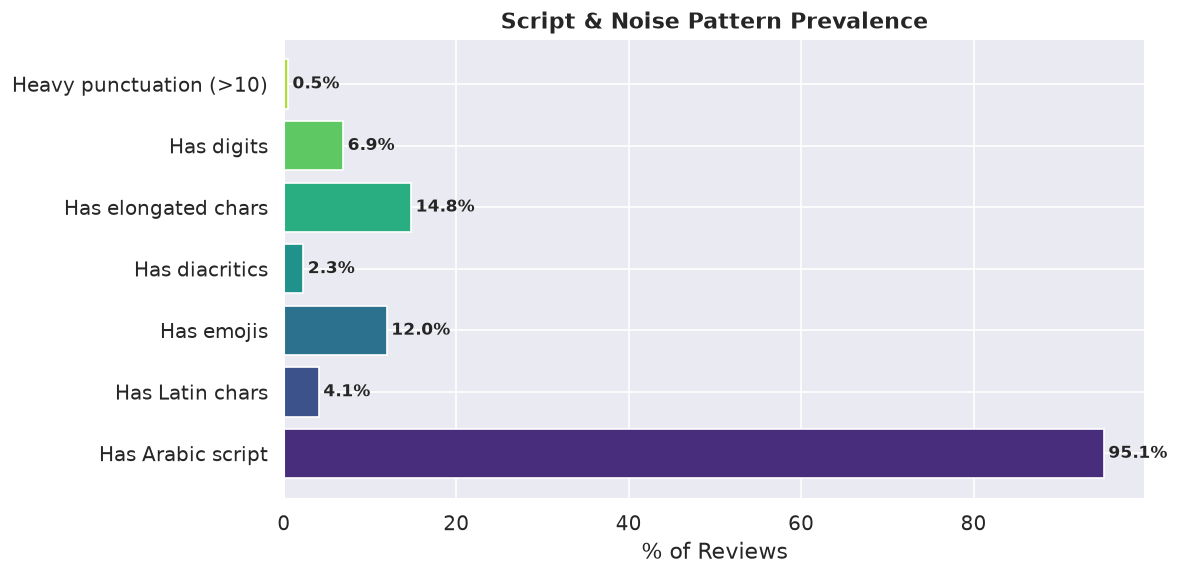

In [38]:
# Visualize noise pattern distribution
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    noise_df.index,
    noise_df["pct (%)"],
    color=sns.color_palette("viridis", len(noise_df)),
)
ax.set_xlabel("% of Reviews")
ax.set_title("Script & Noise Pattern Prevalence", fontweight="bold")
for bar, pct in zip(bars, noise_df["pct (%)"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center",
        fontweight="bold",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

fig.savefig(
    r"../reports/eda/Final_Data_first_data_only/figures/noidse_pattern_dist.png",
    dpi=150,
    bbox_inches="tight",
)

## 6 · Dialect Signal Check
Heuristic pass using dialect-marker word lists to estimate MSA vs. dialectal Arabic mix.


In [ ]:
from raay.data.dialect import DIALECT_MARKERS as dialect_markers

results = {}

for dialect, markers in dialect_markers.items():
    pattern = "|".join(markers)
    count = content.str.contains(
        pattern,
        regex=True,
        na=False,
    ).sum()
    results[dialect] = count

dialect_df = pd.DataFrame(
    {
        "marker_hits": results.values(),
        "pct (%)": [round(v / len(df) * 100, 2) for v in results.values()],
    },
    index=list(results),
)

display(dialect_df.sort_values("pct (%)", ascending=False))

print("\n🔍 Interpretation:")

top = dialect_df["pct (%)"].idxmax()
top_percentage = results[top] / len(df) * 100

print(f"  Dominant signal: {top} ({top_percentage:.1f}%)")

update_section(
    "dialect_signal",
    {
        "markers": dialect_df.to_dict(orient="index"),
        "dominant_signal": top,
        "dominant_signal_percentage": round(top_percentage, 2),
    },
)

,marker_hits,pct (%)
Egyptian,6367,15.90
Levantine,2134,5.33
MSA_formal,1687,4.21
Gulf,1482,3.70



🔍 Interpretation:
  Dominant signal: Egyptian (15.9%)


## 7 · Vocabulary / Frequency Analysis
Top tokens per class + word clouds.

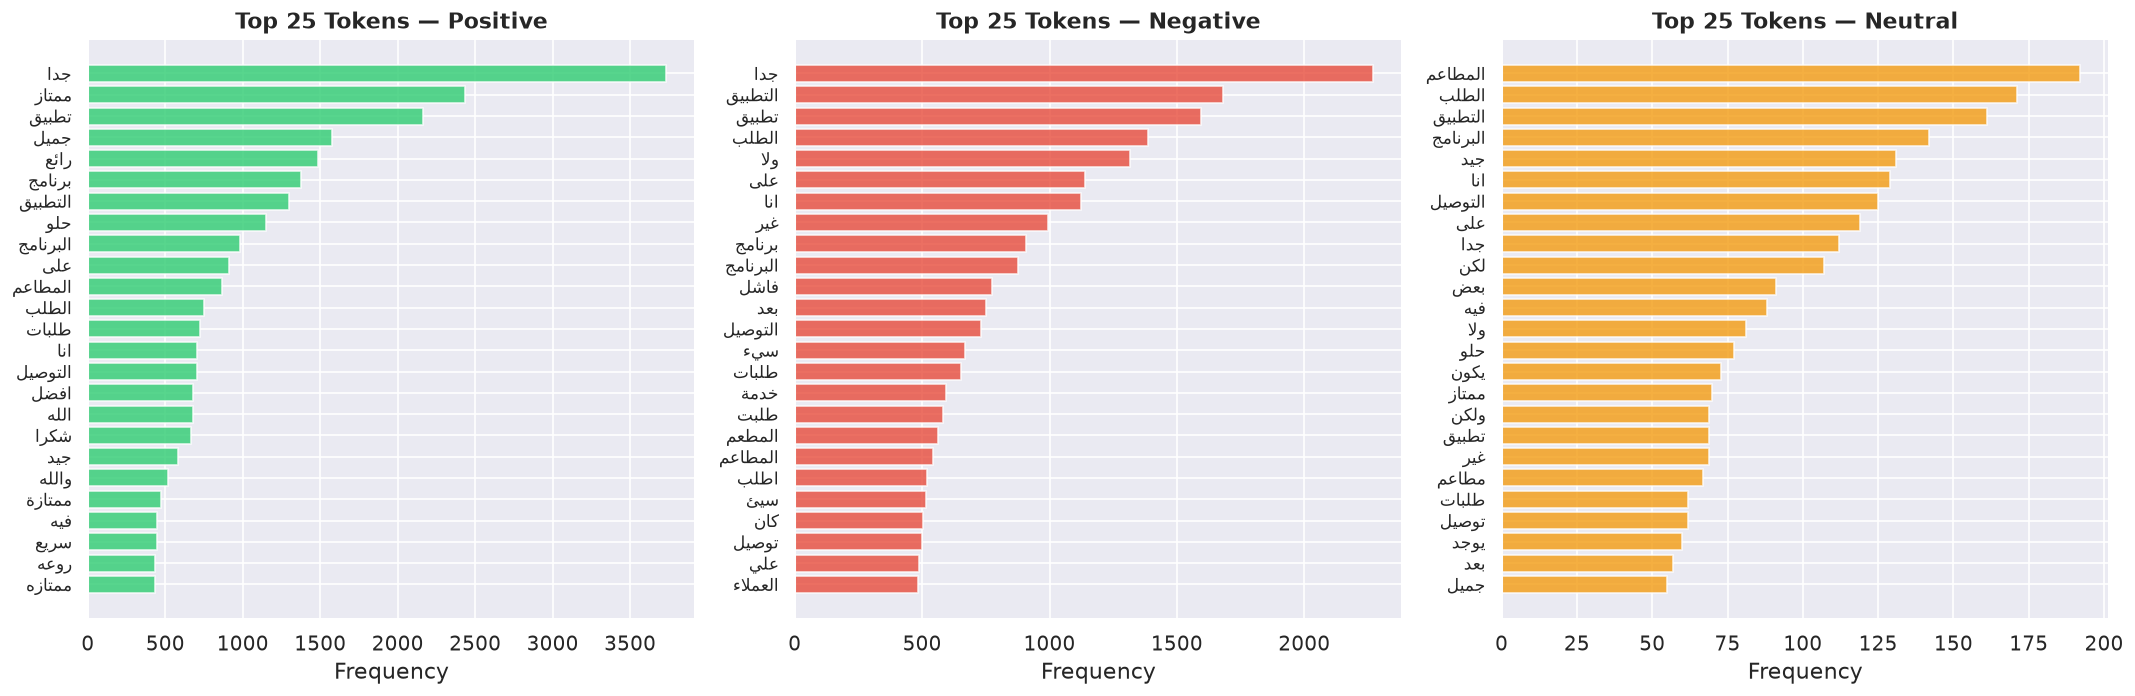

In [40]:
def get_top_tokens(series, n=30):
    """Get top-n tokens from a text series."""
    all_words = " ".join(series.astype(str)).split()
    # Filter very short tokens and common stop-like tokens
    all_words = [w for w in all_words if len(w) > 2]
    return Counter(all_words).most_common(n)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_tokens = {}
for i, (label, color) in enumerate(zip(classes, colors_list)):
    subset = df[df["rating"] == label]["review_description"]
    if subset.empty:
        continue
    top = get_top_tokens(subset, 25)

    top_tokens[label] = [{"token": word, "frequency": count} for word, count in top]

    words, top_counts = zip(*top)
    axes[i].barh(range(len(words)), top_counts, color=color, alpha=0.8)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words, fontsize=10)
    axes[i].invert_yaxis()
    axes[i].set_title(f"Top 25 Tokens — {label.title()}", fontweight="bold")
    axes[i].set_xlabel("Frequency")

update_section("vocabulary", {"top_tokens": top_tokens})

plt.tight_layout()
plt.show()

fig.savefig(
    r"../reports/eda/Final_Data_first_data_only/figures/tokens_frequency.png",
    dpi=150,
    bbox_inches="tight",
)

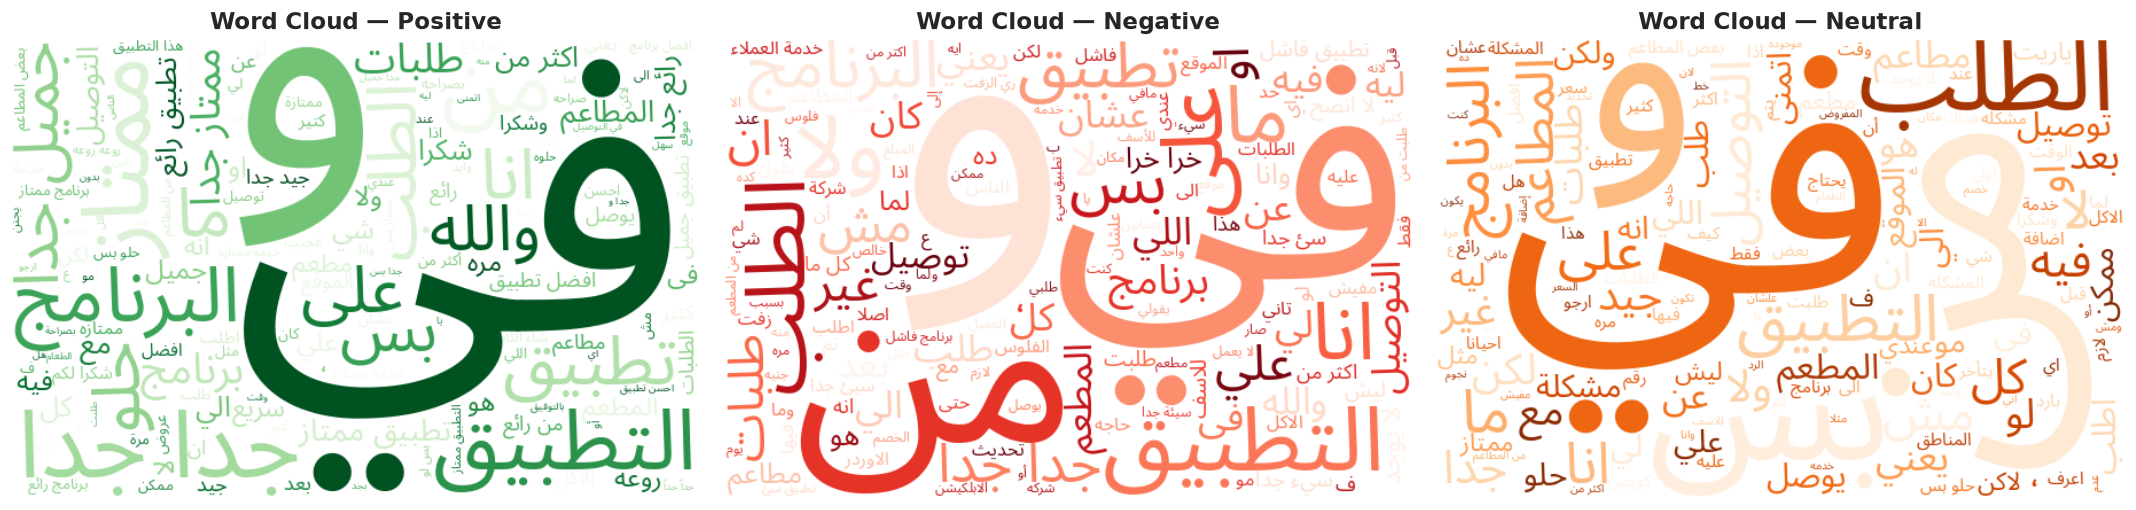

In [41]:
# Word clouds per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmaps = ["Greens", "Reds", "Oranges"]

font_path = "/usr/share/fonts/truetype/noto/NotoSansArabic-Regular.ttf"

for i, (label, cmap) in enumerate(zip(classes, cmaps)):
    text = " ".join(df[df["rating"] == label]["review_description"].astype(str))
    if not text.strip():
        axes[i].axis("off")
        continue
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=cmap,
        max_words=150,
        font_path=font_path,
        regexp=r"[\u0600-\u06FF]+",  # Arabic tokens only
    ).generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Word Cloud — {label.title()}", fontweight="bold", fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

- if the arabic font crash try to install arabic font 
``` bash  
 pip install wordcloud arabic-reshaper python-bidi 
```
- verify 
``` bash
fc-match -f '%{file}\n' "Noto Sans Arabic"
```

## 8 · Company vs. Label Consistency
Check how ratings distribute across companies.


Cross-tab: Company x Rating


rating,negative,neutral,positive,All
company,,,,
Ezz Steel,4,7,38,49
Raya,181,8,79,268
TMG,49,17,184,250
capiter,19,3,51,73
domty,2,0,2,4
elsewedy,39,6,102,147
hilton,34,3,63,100
nestle,14,1,3,18
swvl,1849,318,2526,4693


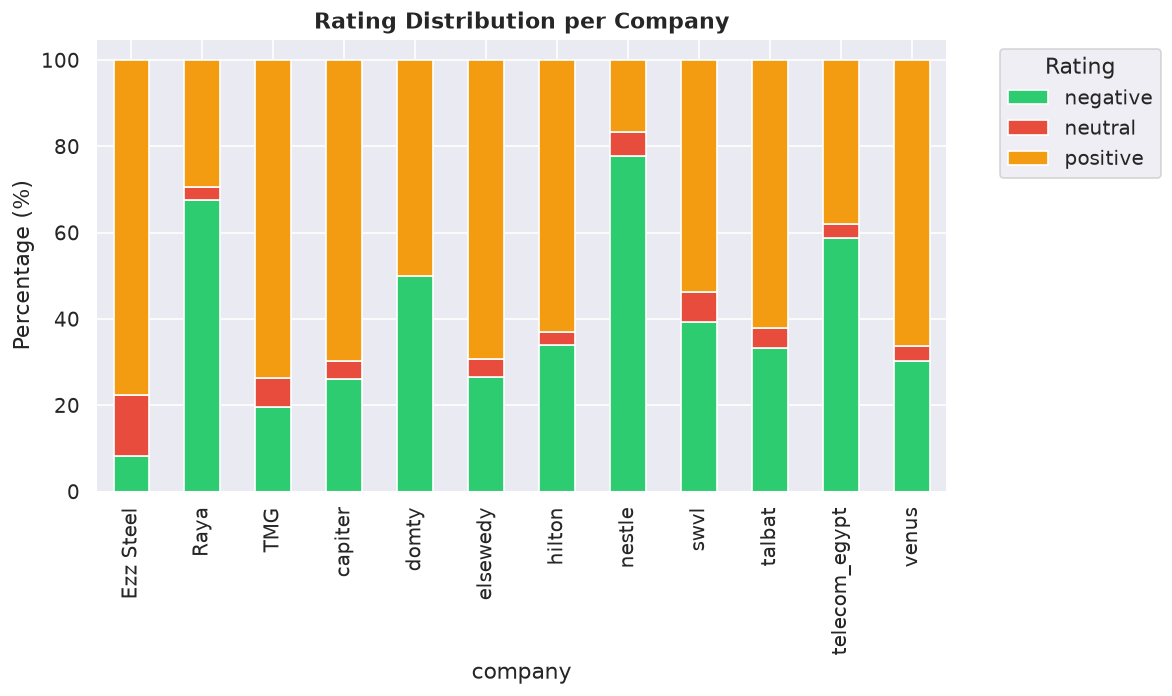

In [42]:
print("\nCross-tab: Company x Rating")
crosstab = pd.crosstab(df["company"], df["rating"], margins=True)
display(crosstab)

# Plot relative distribution per company
crosstab_pct = pd.crosstab(df["company"], df["rating"], normalize="index") * 100
crosstab_pct = crosstab_pct.drop(columns=["All"], errors="ignore").drop(
    index=["All"], errors="ignore"
)

crosstab_pct.plot(kind="bar", stacked=True, figsize=(10, 6), color=colors_list)
plt.title("Rating Distribution per Company", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9 · Outliers
Empty/near-empty reviews, extremely long reviews, all-emoji/no-text reviews.

In [43]:
# Empty / near-empty
near_empty = df[df["char_len"] < 10]
print(f"Near-empty reviews (<10 chars): {len(near_empty)}")
if len(near_empty) > 0:
    display(near_empty[["rating", "review_description", "char_len"]].head(5))

# Very short reviews (< 20 chars)
very_short = df[(df["char_len"] >= 10) & (df["char_len"] < 20)]
print(f"\nVery short reviews (10-19 chars): {len(very_short)}")

update_section(
    "outliers",
    {"near_empty_count": len(near_empty), "very_short_count": len(very_short)},
)

Near-empty reviews (<10 chars): 5949


,rating,review_description,char_len
0,positive,رائع,4
10,positive,ممتاز,5
15,positive,هلا,3
16,positive,جامد,4
18,positive,جيد جدن,7



Very short reviews (10-19 chars): 8437


In [44]:
# Extremely long reviews (top percentile)
p99 = df["char_len"].quantile(0.99)
very_long = df[df["char_len"] > p99]
print(f"Extremely long reviews (>P99 = {p99:.0f} chars): {len(very_long)}")
if len(very_long) > 0:
    print("\nSample of longest reviews:")
    display(very_long.nlargest(5, "char_len")[["rating", "char_len", "word_count"]])

# All-emoji / no-text
emoji_re_full = re.compile(
    "[\U0001f600-\U0001f64f\U0001f300-\U0001f5ff\U0001f680-\U0001f6ff"
    "\U0001f1e0-\U0001f1ff\U00002702-\U000027b0\U0001f900-\U0001f9ff"
    "\U0001fa00-\U0001fa6f\U0001fa70-\U0001faff\U00002600-\U000026ff]"
)
no_text = content.str.replace(emoji_re_full, "", regex=True).str.strip().eq("")
print(f"\nAll-emoji / no-text reviews: {no_text.sum()}")

# Single-word reviews
single_word = df[df["word_count"] == 1]
print(f"Single-word reviews: {len(single_word)}")

Extremely long reviews (>P99 = 349 chars): 401

Sample of longest reviews:


,rating,char_len,word_count
39651,negative,2481,443
39621,positive,1998,374
39917,negative,1897,368
39617,negative,1269,235
22285,negative,1032,258



All-emoji / no-text reviews: 657
Single-word reviews: 4636


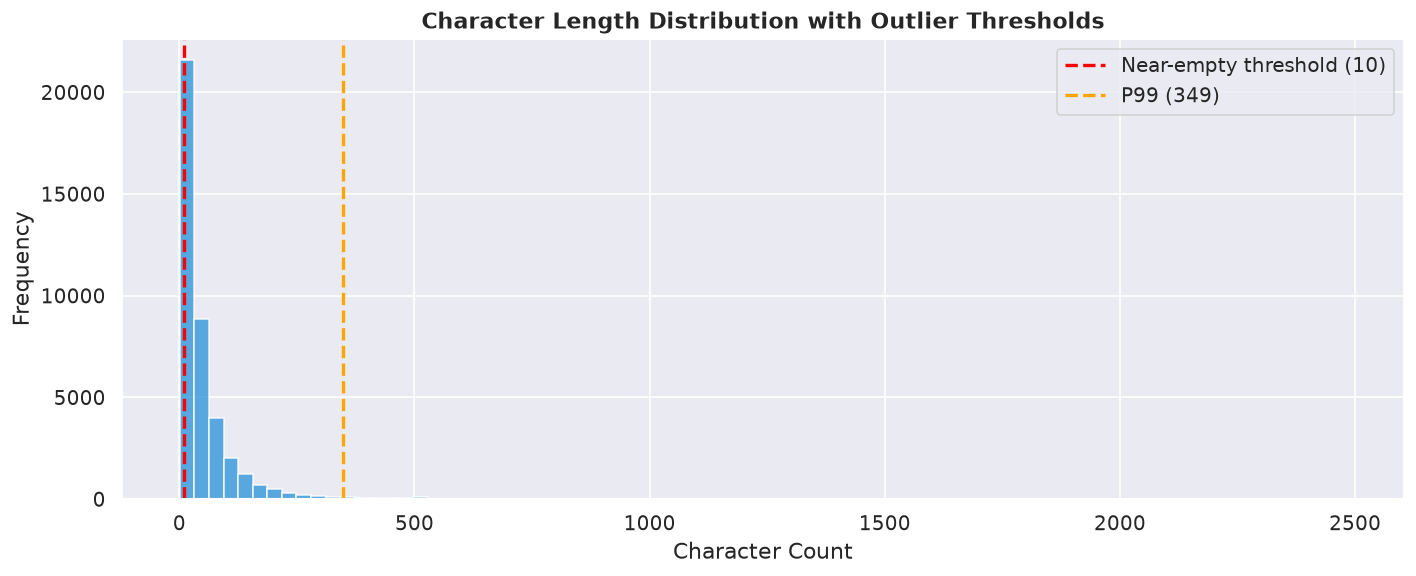

In [45]:
# Outlier summary visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df["char_len"], bins=80, color="#3498db", edgecolor="white", alpha=0.8)
ax.axvline(
    10, color="red", linestyle="--", linewidth=2, label="Near-empty threshold (10)"
)
ax.axvline(p99, color="orange", linestyle="--", linewidth=2, label=f"P99 ({p99:.0f})")
ax.set_title("Character Length Distribution with Outlier Thresholds", fontweight="bold")
ax.set_xlabel("Character Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

## 10 · Findings → Preprocessing Requirements

Based on the analysis above, here are concrete pipeline steps:


In [46]:
# Dynamically generate findings summary
findings = []

# Duplicates
n_exact = df["review_description"].duplicated().sum()
dup_pct = n_exact / len(df) * 100
findings.append(
    f"• {dup_pct:.2f}% exact duplicates → {'dedup step required' if dup_pct > 0.1 else 'minimal duplicates, dedup optional'}"
)

# Label distribution
findings.append(
    f"• Three classes: {counts.get('positive', 0):,} pos / {counts.get('negative', 0):,} neg / {counts.get('neutral', 0):,} neutral"
)
findings.append(
    f"• Highly imbalanced split: {pcts.get('positive', 0):.1f}% / {pcts.get('negative', 0):.1f}% / {pcts.get('neutral', 0):.1f}% → need resampling or class weights (Target is 45/35/20)"
)

# Latin chars
latin_pct = content.str.contains(r"[a-zA-Z]", regex=True).sum() / len(df) * 100
findings.append(
    f"• {latin_pct:.1f}% reviews contain Latin characters → normalization needs Latin-char handling"
)

# Diacritics
diac_pct = (
    content.str.contains(re.compile("[\u064b-\u065f\u0670]")).sum() / len(df) * 100
)
findings.append(
    f"• {diac_pct:.1f}% reviews have diacritics → diacritics stripping step needed"
)

# Elongated chars
elong_pct = content.str.contains(re.compile(r"(.)\1{2,}")).sum() / len(df) * 100
findings.append(
    f"• {elong_pct:.1f}% reviews have elongated characters → normalization needs char-repeat collapsing"
)

# Emojis
emoji_pct = content.str.contains(emoji_re).sum() / len(df) * 100
findings.append(
    f"• {emoji_pct:.2f}% reviews have emojis → decide whether to keep (sentiment bearing) or strip"
)

# Outliers
near_empty_n = (df["char_len"] < 10).sum()
findings.append(
    f"• {near_empty_n} near-empty reviews (<10 chars) → drop or flag for manual review"
)

print("=" * 80)
print("  FINDINGS → PREPROCESSING REQUIREMENTS")
print("=" * 80)
for f in findings:
    print(f)
print("=" * 80)

  FINDINGS → PREPROCESSING REQUIREMENTS
• 2.60% exact duplicates → dedup step required
• Three classes: 23,921 pos / 14,199 neg / 1,925 neutral
• Highly imbalanced split: 59.7% / 35.5% / 4.8% → need resampling or class weights (Target is 45/35/20)
• 4.1% reviews contain Latin characters → normalization needs Latin-char handling
• 2.3% reviews have diacritics → diacritics stripping step needed
• 14.8% reviews have elongated characters → normalization needs char-repeat collapsing
• 11.96% reviews have emojis → decide whether to keep (sentiment bearing) or strip
• 5949 near-empty reviews (<10 chars) → drop or flag for manual review


---

### Summary of Required Pipeline Steps

| # | Step | Rationale |
|---|------|-----------|
| 1 | **Missing Value Drop** | Dropped 1 row with null review_description |
| 2 | **Deduplication** | Remove exact/near duplicates to prevent data leakage |
| 3 | **Class Rebalancing** | Highly imbalanced: ~60% pos / ~35% neg / ~5% neutral (Target: 45/35/20) |
| 4 | **Whitespace & Char repeat normalization** | Many reviews contain elongated chars |
| 5 | **Emoji Handling** | Emojis present, usually useful for sentiment |
| 6 | **Diacritic Removal** | Standardize text representation |
| 7 | **Near-empty Filtering** | Drop reviews < 10 chars |

---